# Introdução

: Apresentação do contexto, do modelo formal por trás da hipótese e descrição clara da própria hipótese

Contextualização da desigualdade em SP e a apresentação do **Modelo Formal**.
- **Modelo Formal:** Exemplo: $Nota = \beta_0 + \beta_1(EscolaridadePais) + \beta_2(Renda) + \epsilon$. 
- **Hipótese:** Existe uma disparidade significativa nas notas do ENEM entre diferentes zonas de SP, correlacionada com indicadores socioeconômicos locais.

# Dados

descrição da base de dados e suas principais características

carrega o CSV do ENEM e faz os primeiros filtros
- `df.info()`, `df.describe()` e `df.shape`
- Fonte
- limpeza
- estatística descritiva

## Merge

In [2]:
import pandas as pd

# 1. Carregar seus dados processados do ENEM
df_enem = pd.read_csv('data/processed/enem_sp_completo_agrupado.csv')

# 2. Carregar o diretório de municípios (para garantir os nomes e siglas corretas)
df_dicionario_sp = pd.read_csv('data/raw/br_bd_diretorios_brasil_municipio.csv.gz')
df_dicionario_sp = df_dicionario_sp[df_dicionario_sp['sigla_uf'] == 'SP'][['id_municipio', 'nome']]

# 3. Carregar os dados de IDH/Infraestrutura
df_idh = pd.read_csv('data/raw/mundo_onu_adh_municipio.csv.gz')
# Filtrar apenas o ano mais recente (2010) para não duplicar linhas
df_idh = df_idh[df_idh['ano'] == 2010]

# Primeiro: Unimos o ENEM com o diretório para ter os nomes corretos das cidades
df = df_enem.merge(df_dicionario_sp, left_on='CO_MUNICIPIO_ESC', right_on='id_municipio')

# Segundo: Unimos com os dados de IDH/Infraestrutura
df = df.merge(df_idh, on='id_municipio')

# Visualizar o resultado
print(f"Total de municípios após o merge: {len(df)}")
municipios_sp = df['nome'].unique().tolist()
municipios_sp.sort()
print(f"Municípios de SP presentes no dataset: {municipios_sp}")
print(df.columns.tolist())

Total de municípios após o merge: 644
Municípios de SP presentes no dataset: ['Adamantina', 'Adolfo', 'Aguaí', 'Agudos', 'Alambari', 'Alfredo Marcondes', 'Altair', 'Altinópolis', 'Alto Alegre', 'Alumínio', 'Alvinlândia', 'Americana', 'Amparo', 'Américo Brasiliense', 'Américo de Campos', 'Analândia', 'Andradina', 'Angatuba', 'Anhembi', 'Anhumas', 'Aparecida', "Aparecida d'Oeste", 'Apiaí', 'Aramina', 'Arandu', 'Arapeí', 'Araraquara', 'Araras', 'Araçariguama', 'Araçatuba', 'Araçoiaba da Serra', 'Arco-Íris', 'Arealva', 'Areias', 'Areiópolis', 'Ariranha', 'Artur Nogueira', 'Arujá', 'Aspásia', 'Assis', 'Atibaia', 'Auriflama', 'Avanhandava', 'Avaré', 'Avaí', 'Bady Bassitt', 'Balbinos', 'Bananal', 'Barbosa', 'Bariri', 'Barra Bonita', 'Barra do Chapéu', 'Barra do Turvo', 'Barretos', 'Barrinha', 'Barueri', 'Barão de Antonina', 'Bastos', 'Batatais', 'Bauru', 'Bebedouro', 'Bento de Abreu', 'Bernardino de Campos', 'Bertioga', 'Bilac', 'Birigui', 'Biritiba-Mirim', 'Boa Esperança do Sul', 'Bocaina', 

## Feature engineering

In [ ]:
df['nota_final'] = (df["NU_NOTA_CN"]+df['NU_NOTA_CH']+ df['NU_NOTA_LC'] +df['NU_NOTA_MT']+ df['NU_NOTA_REDACAO'])/5
municipios = ['Ferraz de Vasconcelos', 'Indaiatuba', 'Jundiaí', 'Itaquaquecetuba', 'São Paulo', 'Poá', 'Osasco','Guarulhos','São Bernardo' ]
for i in municipios:
    df1 = df[df['nome']== i]
    colunas = ["nome",'nota_final', "idhm"]
    print(df1[colunas])
    print("---"*30)

# Média do Brasil é 546

                      nome  nota_final   idhm
180  Ferraz de Vasconcelos  520.019765  0.738
------------------------------------------------------------------------------------------
           nome  nota_final   idhm
235  Indaiatuba  559.793855  0.788
------------------------------------------------------------------------------------------
        nome  nota_final   idhm
293  Jundiaí  575.006047  0.822
------------------------------------------------------------------------------------------
                nome  nota_final   idhm
264  Itaquaquecetuba  515.023617  0.714
------------------------------------------------------------------------------------------
          nome  nota_final   idhm
561  São Paulo  558.513053  0.805
------------------------------------------------------------------------------------------
    nome  nota_final   idhm
444  Poá  523.364329  0.771
------------------------------------------------------------------------------------------
       nome  nota_final 

In [ ]:

# Colunas de interesse:
colunas = ['nome', 'nota_final', 'id_municipio', 'idhm', "idhm_e", "idhm_l", "idhm_r", "indice_frequencia_escolar", "indice_escolaridade","taxa_sem_energia_eletrica", "taxa_agua_encanada", 'taxa_atividade_15_17', 'renda_media_ocupados', 'renda_pc', 'renda_pc_pobreza_extrema', 'prop_vulner_pobreza_criancas', 'prop_pobreza', 'indice_gini', 'prop_pobreza_criancas','taxa_freq_fundamental_15_17', 'taxa_analfabetismo_15_a_17']
df_final = df[colunas]
print(df_final.head())

               nome  nota_final  id_municipio   idhm  idhm_e  idhm_l  idhm_r  \
0        Adamantina  571.076814       3500105  0.790   0.750   0.852   0.772   
1            Adolfo  506.822308       3500204  0.730   0.648   0.844   0.710   
2             Aguaí  509.269302       3500303  0.715   0.606   0.858   0.703   
3    Águas da Prata  552.307500       3500402  0.781   0.716   0.886   0.750   
4  Águas de Lindóia  556.668736       3500501  0.745   0.675   0.846   0.725   

   indice_frequencia_escolar  indice_escolaridade  taxa_sem_energia_eletrica  \
0                      0.833                0.608                       0.03   
1                      0.788                0.439                       0.00   
2                      0.690                0.467                       0.00   
3                      0.814                0.554                       0.00   
4                      0.776                0.510                       0.00   

   ...  taxa_atividade_15_17  renda_me

# Resultados

## Gráficos de dispersão

## Matriz de correlação

Apresentação das evidências empíricas relacionadas à hipótese (gráficos e estatísticas)

Gráficos (quais?) e o que cada um revela sobre a hipótese inicial

In [ ]:
import pandas as pd
variavel_de_notas = ''
# Calculamos a correlação pelos metodos de spearman e pearson para descobrirmos as variaveis que mais se correlacionam com a nota a fim de compará-las
spearman = df.corr(method='spearman')['variavel_de_notas'].abs()
pearson = df.corr(method='pearson')['variavel_de_notas'].abs()
# Visualização dos resultados do método spearman
print('Váriaveis que mais se relacionam com a nota pelo método Spearman')
maiores_spearman = spearman.sort_values(ascending=False).head()
print(maiores_spearman)
# Visualização dos resultados do método pearson
print('Váriaveis que mais se relacionam com a nota pelo método Pearson')
maiores_pearson = pearson.sort_values(ascending=False).head()
print(maiores_pearson)

### Correlação positiva

### Correlação negativa

### Correlação fracas

## Geopandas

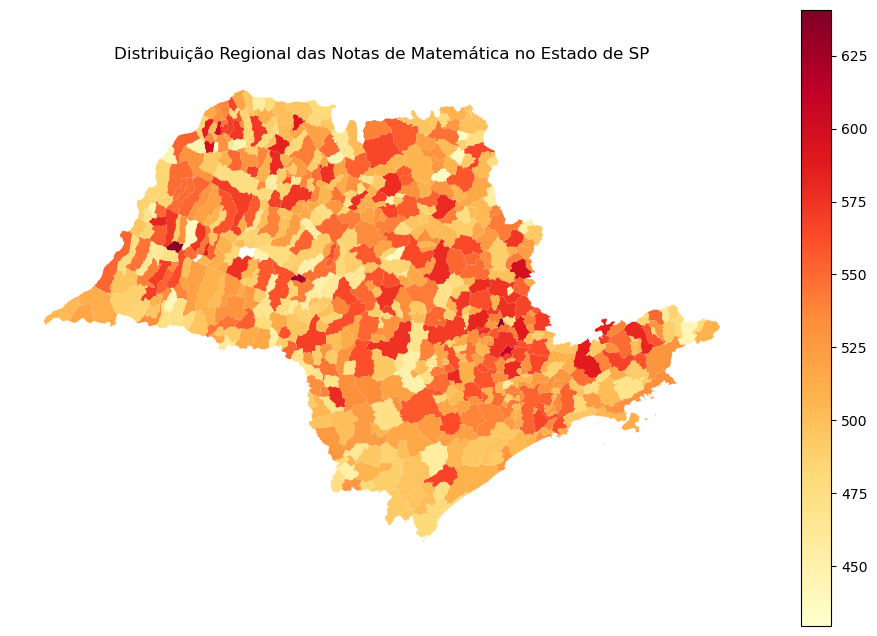

In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Carregar o mapa de municípios de SP que baixou
mapa_sp = gpd.read_file('data/shp/SP_Municipios_2024.shp')

# Garantir que o ID do município é string para o cruzamento
mapa_sp['CD_MUN'] = mapa_sp['CD_MUN'].astype(str)
df['id_municipio'] = df['id_municipio'].astype(str)

# Unir os dados alfanuméricos com o mapa geométrico
mapa_final = mapa_sp.merge(df, left_on='CD_MUN', right_on='id_municipio')

# Plotar o mapa de calor da nota de Matemática
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
mapa_final.plot(column='NU_NOTA_MT', cmap='YlOrRd', legend=True, ax=ax)
plt.title('Distribuição Regional das Notas de Matemática no Estado de SP')
plt.axis('off')
plt.show()

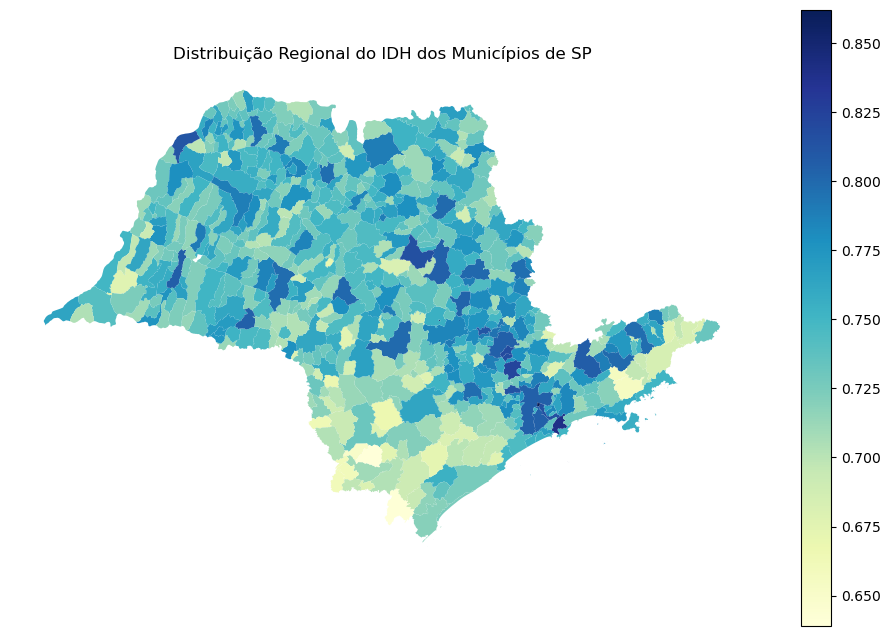

In [ ]:
# Criar o mapa de calor para idh_municipio
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
mapa_final.plot(column='idhm', cmap='YlGnBu', legend=True, ax=ax)
plt.title('Distribuição Regional do IDH dos Municípios de SP')
plt.axis('off')
plt.show()


# Conclusão

Considerações finais e sugestões de passos futuros para enriquecimento da análise
- evidências foram favoráveis ou contrárias à hipótese
- Sugerir aprofundamentos
